In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

from utils import (
    fetch_market_data, parse_future_name, candle_to_bounds,
    compute_segment_carry, interpolate_forward, compute_continuous_forward_curve, add_mid_prices
)


In [3]:
# Fetch candlestick data over a longer period (much faster than orderbook)
# Note: Candlestick data (module 2) is only available from 2024-06-01 onwards
start_date = datetime(2024, 6, 1)
end_date = datetime(2024, 12, 31)
inst_family = 'BTC-USD'
verbose = True

# Fetch SWAP candles
swap_candles = fetch_market_data(
    '2', 'SWAP', inst_family, start_date, end_date, 'daily',
    verbose=verbose
)

# Fetch FUTURES candles
futures_candles = fetch_market_data(
    '2', 'FUTURES', inst_family, start_date, end_date, 'daily',
    verbose=verbose
)


Fetching SWAP data (module=2) for BTC-USD
Period: 2024-06-01 00:00:00 to 2024-12-31 00:00:00
Split into 11 requests


Fetching data:   0%|          | 0/11 [00:00<?, ?it/s]

Fetch #1/11: 20 files found | Total: 20 files, 0.59 MB


Fetch #2/11: 20 files found | Total: 40 files, 1.18 MB


Fetch #3/11: 20 files found | Total: 60 files, 1.78 MB


...

Fetch #8/11: 20 files found | Total: 152 files, 14.49 MB


Fetch #9/11: 20 files found | Total: 172 files, 16.86 MB


Fetch #10/11: 20 files found | Total: 192 files, 18.96 MB


Fetch #11/11: 14 files found | Total: 206 files, 20.47 MB


✓ Successfully fetched 1780110 records


In [10]:
print(f"Swap earliest date: {pd.to_datetime(swap_candles['open_time'].min(), unit='ms')}")
print(f"Swap latest date: {pd.to_datetime(swap_candles['open_time'].max(), unit='ms')}")
print(f"Futures earliest date: {pd.to_datetime(futures_candles['open_time'].min(), unit='ms')}")
print(f"Futures latest date: {pd.to_datetime(futures_candles['open_time'].max(), unit='ms')}")

Swap earliest date: 2024-05-31 16:00:00
Swap latest date: 2024-12-31 15:59:00
Futures earliest date: 2024-05-31 16:00:00
Futures latest date: 2024-12-31 15:59:00


In [8]:
# Convert candlestick data to orderbook-like format
swap_df = candle_to_bounds(swap_candles)
futures_df = candle_to_bounds(futures_candles)

# Parse futures expiries
futures_df['expiry'] = futures_df['symbol'].apply(lambda x: parse_future_name(x)[1])

print(f"Swap candles: {len(swap_df)}")
print(f"Futures candles: {len(futures_df)}")
print(f"Unique futures symbols: {futures_df['symbol'].nunique()}")
print(f"Time range: {swap_df['time_bin'].min()} to {swap_df['time_bin'].max()}")
print(f"\nNote: Using high/low as bid/ask bounds from candlestick data")


Swap candles: 296685
Futures candles: 1780110
Unique futures symbols: 36
Time range: 2024-05-31 16:00:00 to 2024-12-31 15:59:00

Note: Using high/low as bid/ask bounds from candlestick data


In [ ]:
# Compute segment carry rates at a single timestamp
example_time = swap_df['time_bin'].iloc[len(swap_df)//2]  # Middle of dataset
swap_row = swap_df[swap_df['time_bin'] == example_time].iloc[0]
swap_bid, swap_ask = swap_row['bid_1_px'], swap_row['ask_1_px']
futures_at_time = futures_df[futures_df['time_bin'] == example_time].copy()

segments = compute_segment_carry(futures_at_time, swap_bid, swap_ask, example_time)
segments = add_mid_prices(segments)

print(f"\nSegment carry rates at {example_time}:")
print(segments[['symbol_start', 'symbol_end', 'T_start', 'T_end', 
                'carry_lower', 'carry_upper', 'carry_mid']].to_string(index=False))



Segment carry rates at 2024-09-25 15:37:00:
  symbol_start     symbol_end  T_start    T_end  carry_lower_pct  carry_upper_pct  carry_mid_pct
          SWAP BTC-USD-240927 0.000000 0.004550        -4.999259       -11.469759      -8.234509
BTC-USD-240927 BTC-USD-241004 0.004550 0.023715         7.345812         2.976344       5.161078
BTC-USD-241004 BTC-USD-241025 0.023715 0.081210         5.775177         5.802335       5.788756
BTC-USD-241025 BTC-USD-241129 0.081210 0.177034         6.350229         6.333935       6.342082
BTC-USD-241129 BTC-USD-241227 0.177034 0.253694         7.080593         7.811296       7.445944
BTC-USD-241227 BTC-USD-250328 0.253694 0.502839        10.293191        10.315262      10.304227


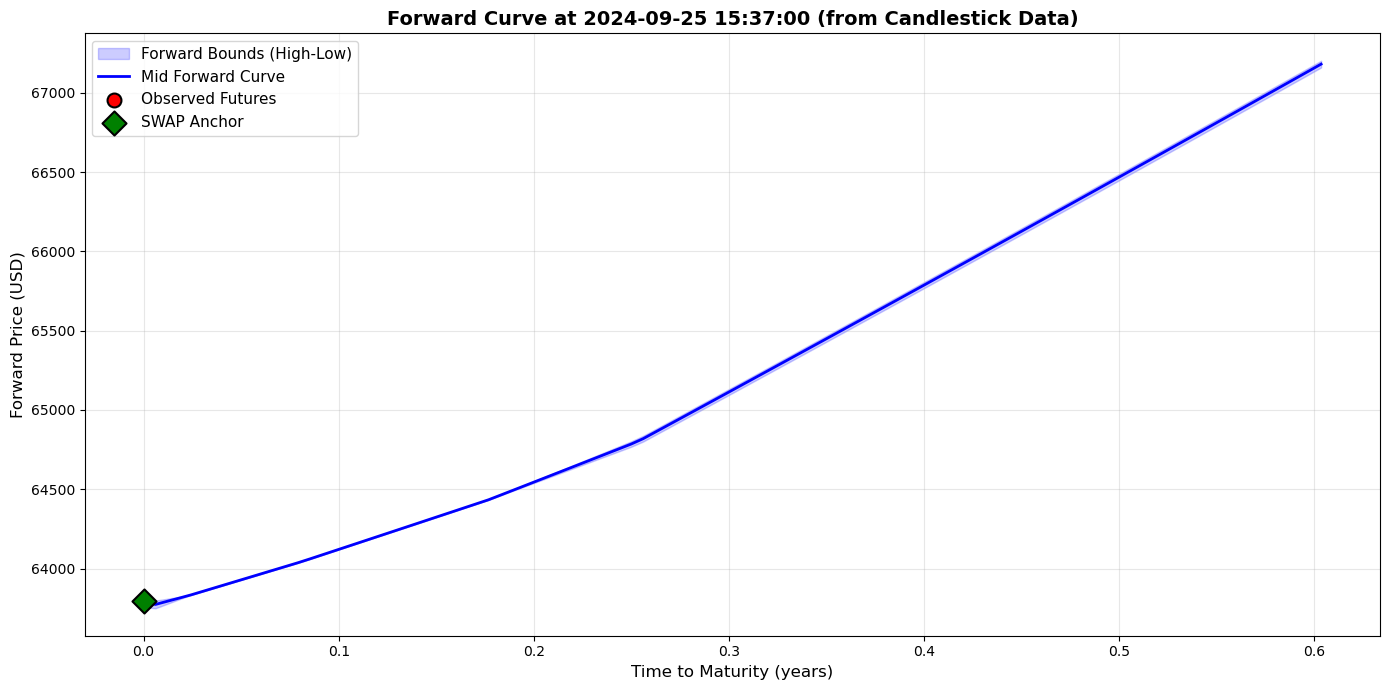

In [12]:
# Compute continuous forward curve
T_max = segments['T_end'].max()
T_grid = np.linspace(0, T_max * 1.2, 100)

forward_curve = compute_continuous_forward_curve(futures_at_time, swap_bid, swap_ask, example_time, T_grid)
forward_curve = add_mid_prices(forward_curve)

# Plot forward curve
fig, ax = plt.subplots(1, 1, figsize=(14, 7))

observed = forward_curve[forward_curve['source'] == 'observed']
interpolated = forward_curve[forward_curve['source'].isin(['interpolated', 'swap'])]

ax.fill_between(interpolated['T'], interpolated['F_lower'], interpolated['F_upper'], 
                alpha=0.2, color='blue', label='Forward Bounds (High-Low)')
ax.plot(interpolated['T'], interpolated['F_mid'], 'b-', linewidth=2, label='Mid Forward Curve')
ax.scatter(observed['T'], observed['F_mid'], color='red', s=100, zorder=3, 
          label='Observed Futures', edgecolors='black', linewidth=1.5)

swap_point = forward_curve[forward_curve['source'] == 'swap'].iloc[0]
ax.scatter([swap_point['T']], [(swap_point['F_lower'] + swap_point['F_upper'])/2], 
          color='green', s=150, zorder=4, marker='D', 
          label='SWAP Anchor', edgecolors='black', linewidth=1.5)

ax.set_xlabel('Time to Maturity (years)', fontsize=12)
ax.set_ylabel('Forward Price (USD)', fontsize=12)
ax.set_title(f'Forward Curve at {example_time} (from Candlestick Data)', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


In [13]:
# Compute segment carry rates over ALL timestamps
all_segments = []

for _, swap_row in tqdm(swap_df.iterrows(), total=len(swap_df), desc="Computing segments"):
    time_bin = swap_row['time_bin']
    swap_bid, swap_ask = swap_row['bid_1_px'], swap_row['ask_1_px']
    
    futures_at_time = futures_df[futures_df['time_bin'] == time_bin].copy()
    if len(futures_at_time) == 0:
        continue
    
    segments_df = compute_segment_carry(futures_at_time, swap_bid, swap_ask, time_bin)
    segments_df = add_mid_prices(segments_df)
    segments_df['time_bin'] = time_bin
    all_segments.append(segments_df)

all_segments_df = pd.concat(all_segments, ignore_index=True)

print(f"\nComputed {len(all_segments_df)} segment observations across time")
print(f"Time range: {all_segments_df['time_bin'].min()} to {all_segments_df['time_bin'].max()}")


Computing segments:   0%|          | 0/296685 [00:00<?, ?it/s]


Computed 1780650 segment observations across time
Time range: 2024-05-31 16:00:00 to 2024-12-31 15:59:00


In [ ]:
print(all_segments_df.columns)

Index(['T_start', 'T_end', 'F_lower_start', 'F_lower_end', 'F_upper_start',
       'F_upper_end', 'carry_lower', 'carry_upper', 'carry_lower_pct',
       'carry_upper_pct', 'expiry_start', 'expiry_end', 'symbol_start',
       'symbol_end', 'F_mid_start', 'F_mid_end', 'carry_mid', 'carry_mid_pct',
       'time_bin', 'segment_label'],
      dtype='object')


In [17]:
print(all_segments_df.head())

    T_start     T_end  F_lower_start  F_lower_end  F_upper_start  F_upper_end  \
0  0.000000  0.015457        66274.8      66357.5        66308.0      66357.5   
1  0.015457  0.034622        66357.5      66413.6        66357.5      66439.1   
2  0.034622  0.111282        66413.6      66896.2        66439.1      66896.2   
3  0.111282  0.207107        66896.2      67636.7        66896.2      67669.9   
4  0.207107  0.283767        67636.7      68191.1        67669.9      68236.5   

   carry_lower  carry_upper  carry_lower_pct  carry_upper_pct  \
0     0.080677     0.048277         8.067676         4.827690   
1     0.044094     0.064125         4.409420         6.412471   
2     0.094447     0.089440         9.444725         8.943962   
3     0.114882     0.120003        11.488230        12.000349   
4     0.106488     0.108768        10.648763        10.876806   

         expiry_start          expiry_end    symbol_start      symbol_end  \
0 2024-06-15 16:00:00 2024-06-21 07:30:00    

/var/folders/fl/fdwpgpsx7fx15p__07t93bhr0000gn/T/ipykernel_15767/1616683027.py:43: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


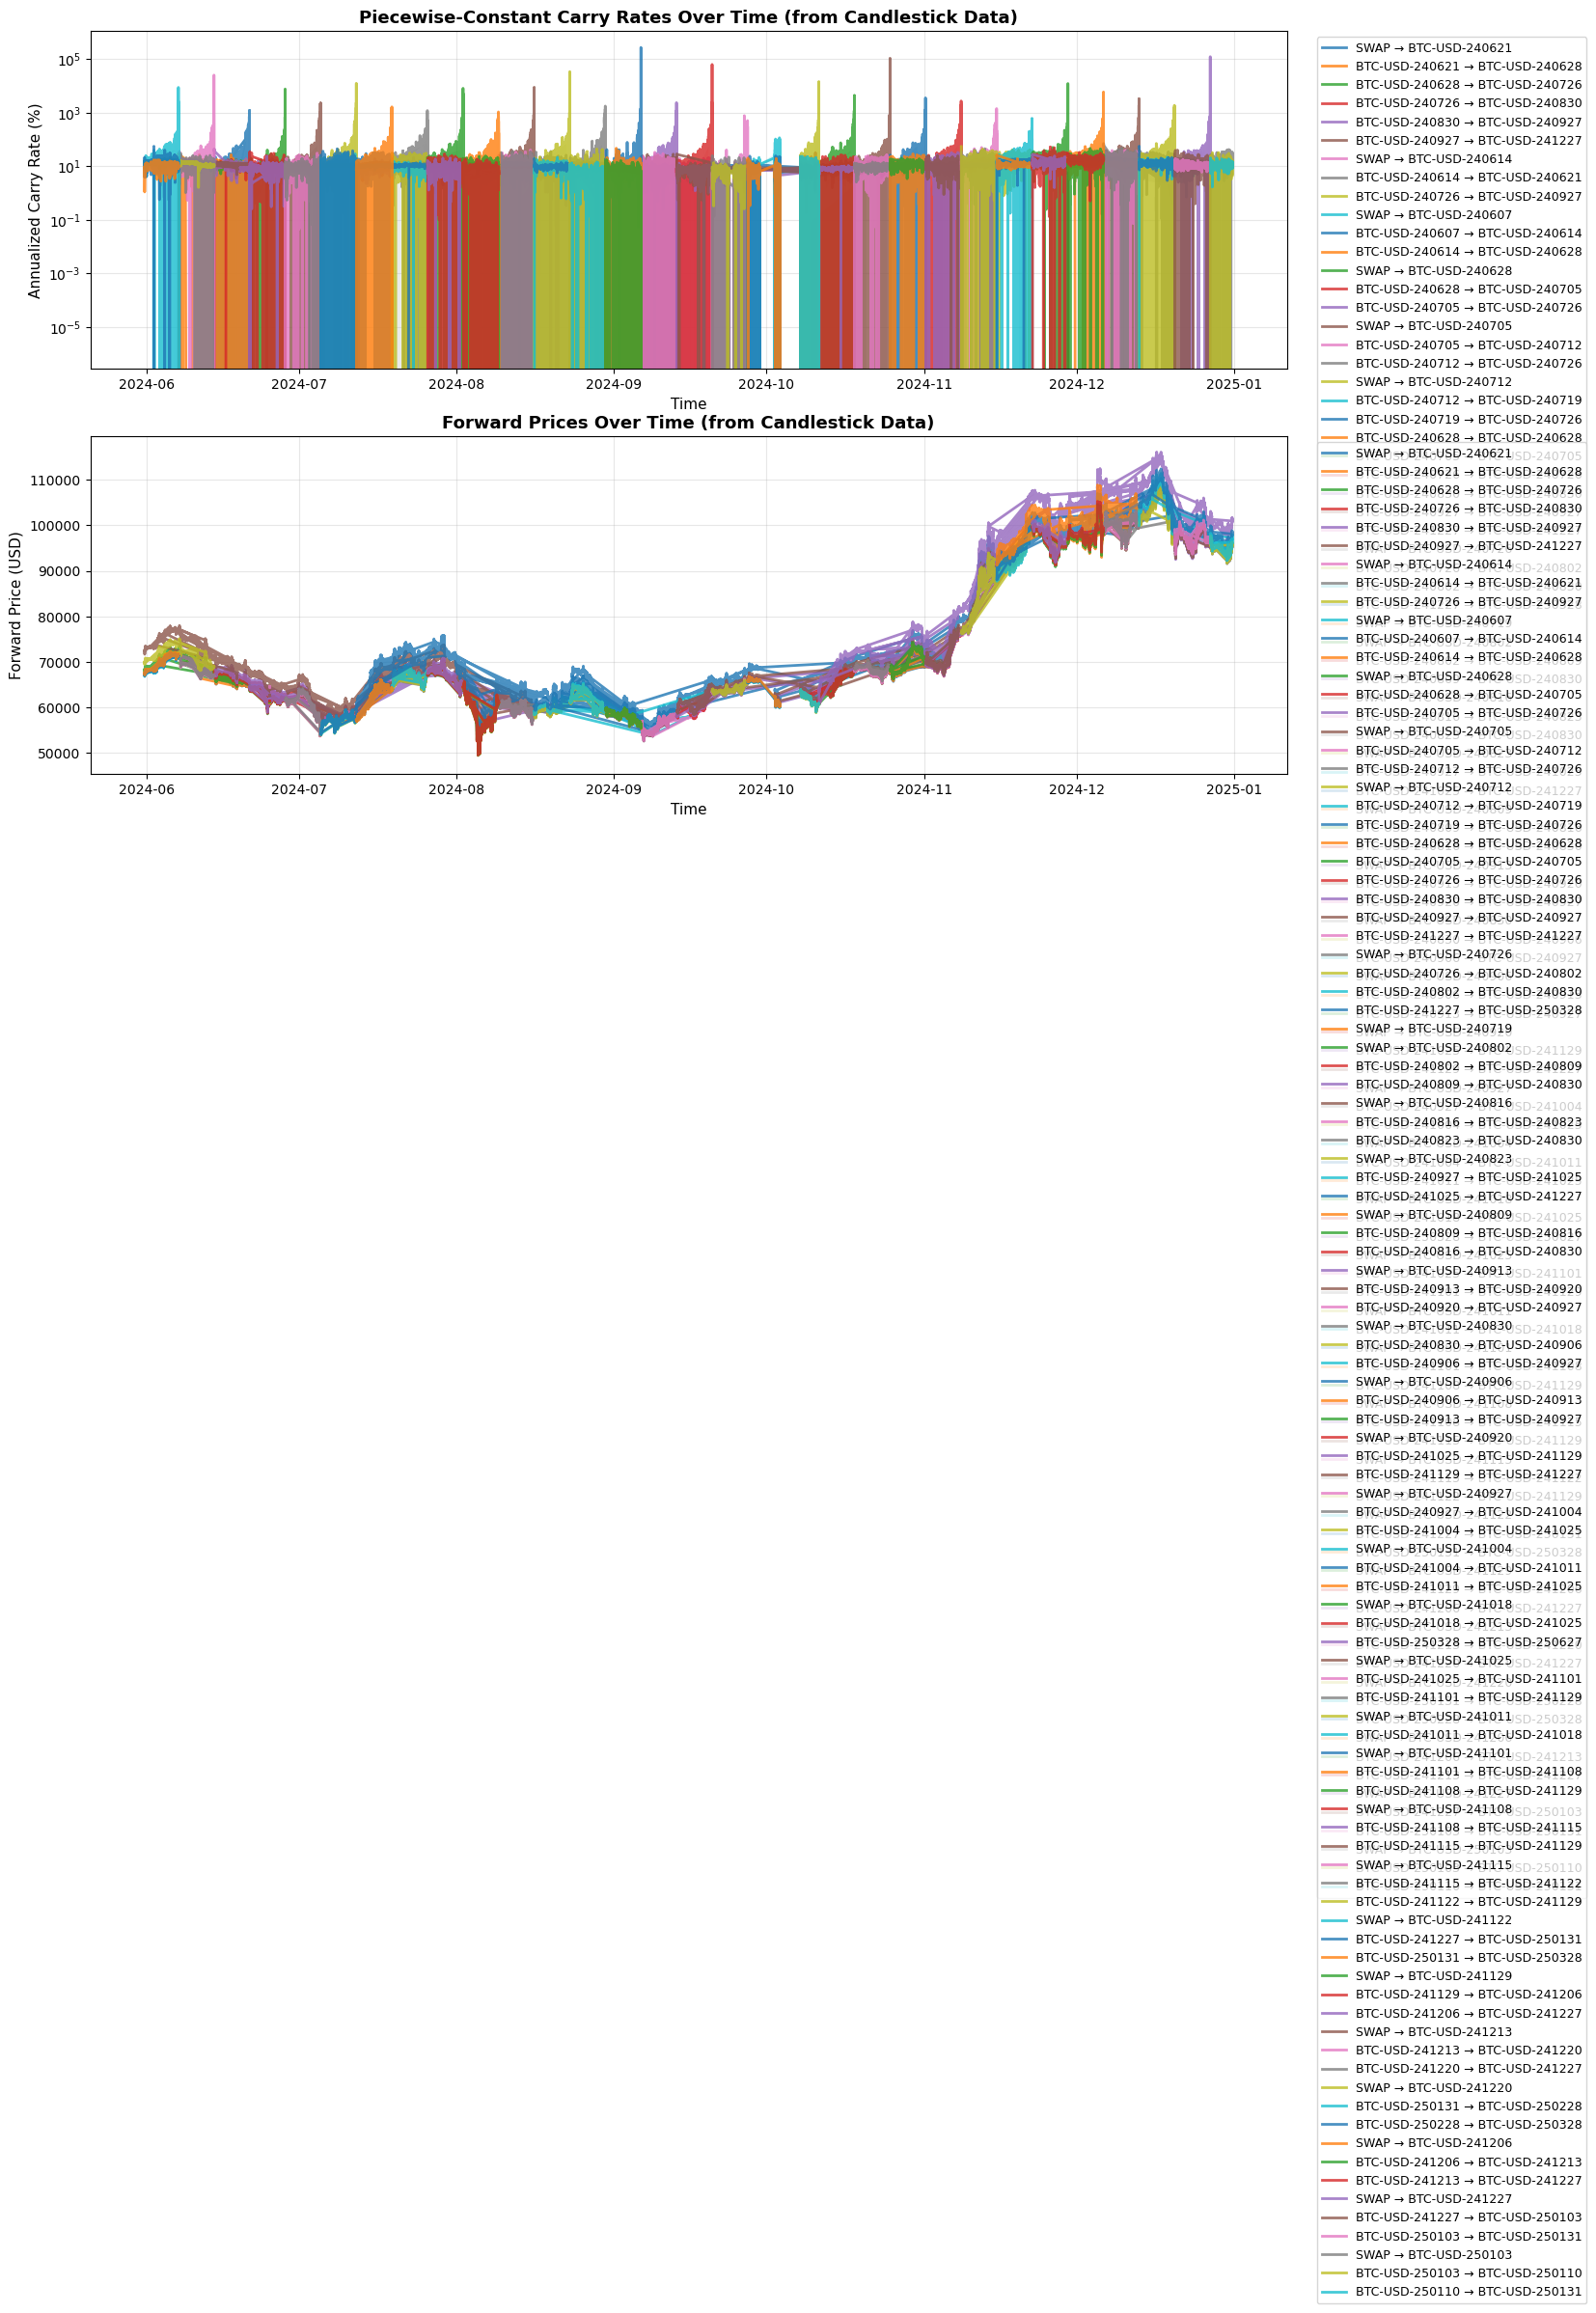

In [ ]:
# Time series plots with bounds
fig, axes = plt.subplots(2, 1, figsize=(16, 10))

all_segments_df['segment_label'] = all_segments_df['symbol_start'] + ' → ' + all_segments_df['symbol_end']

# Plot 1: Carry rates with bounds
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    
    axes[0].plot(segment_data['time_bin'], segment_data['carry_mid']*100, 
                 label=segment_label, linewidth=2, alpha=0.8)
    
    axes[0].fill_between(segment_data['time_bin'], 
                         segment_data['carry_lower']*100, 
                         segment_data['carry_upper']*100,
                         alpha=0.15)

axes[0].set_xlabel('Time', fontsize=11)
axes[0].set_ylabel('Annualized Carry Rate (%)', fontsize=11)
axes[0].set_title('Piecewise-Constant Carry Rates Over Time (from Candlestick Data)', fontsize=13, fontweight='bold')
axes[0].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].set_yscale('log')

# Plot 2: Forward prices with bounds
for segment_label in all_segments_df['segment_label'].unique():
    segment_data = all_segments_df[all_segments_df['segment_label'] == segment_label]
    
    axes[1].plot(segment_data['time_bin'], segment_data['F_mid_end'], 
                 label=segment_label, linewidth=2, alpha=0.8)
    
    axes[1].fill_between(segment_data['time_bin'], 
                         segment_data['F_lower_end'], 
                         segment_data['F_upper_end'],
                         alpha=0.15)

axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylabel('Forward Price (USD)', fontsize=11)
axes[1].set_title('Forward Prices Over Time (from Candlestick Data)', fontsize=13, fontweight='bold')
axes[1].legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# Summary statistics
summary = all_segments_df.groupby('segment_label').agg({
    'carry_mid_pct': ['mean', 'std', 'min', 'max'],
    'carry_lower_pct': ['mean', 'std'],
    'carry_upper_pct': ['mean', 'std'],
    'T_start': 'first',
    'T_end': 'first'
}).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.sort_values('T_start_first')

print("\nCarry Rate Statistics by Segment (Full Period):")
print(summary)


In [ ]:
# Plot carry rate distribution and swap price history
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot of carry rates by segment
segment_labels = sorted(all_segments_df['segment_label'].unique(), 
                       key=lambda x: all_segments_df[all_segments_df['segment_label']==x]['T_start'].iloc[0])
carry_data = [all_segments_df[all_segments_df['segment_label']==seg]['carry_mid_pct'].values 
              for seg in segment_labels]

axes[0].boxplot(carry_data, labels=[seg.split(' → ')[1] for seg in segment_labels], vert=True)
axes[0].set_xlabel('Segment End', fontsize=11)
axes[0].set_ylabel('Annualized Carry Rate (%)', fontsize=11)
axes[0].set_title('Distribution of Carry Rates by Segment', fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3, axis='y')
axes[0].tick_params(axis='x', rotation=45)

# Time series of swap price with bounds
swap_df_sorted = swap_df.sort_values('time_bin')
axes[1].fill_between(swap_df_sorted['time_bin'], 
                     swap_df_sorted['bid_1_px'], 
                     swap_df_sorted['ask_1_px'],
                     alpha=0.3, label='High-Low Bounds')
axes[1].plot(swap_df_sorted['time_bin'], 
            (swap_df_sorted['bid_1_px'] + swap_df_sorted['ask_1_px']) / 2,
            'b-', linewidth=1.5, label='Mid Price')
axes[1].set_xlabel('Time', fontsize=11)
axes[1].set_ylabel('SWAP Price (USD)', fontsize=11)
axes[1].set_title('BTC-USD Perpetual Swap Price', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
